In [2]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 11])

nb_name = "annotation.ipynb"

_compare_version(nb_name)

# Cell type annotation and marker list assembly
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

This Jupyter Notebook is designed for annotating cell types in clustered AnnData objects. It is divided into two main parts:

- **Marker List Assembly**: This part is used when no existing marker lists are available. It enables users to assemble custom marker lists using the MarkerRepo.

- **Annotation**: This section applies the created or provided marker lists to annotate cell types in AnnData objects.


For more information about MarkerRepo, click [here](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features).

--------------

## 2- Setup

In [3]:
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.plotting as pl
import os
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown

settings.settings_from_config("config.yaml", key="annoation")

[WARNING] Log file '../logs/annotation_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.
Created directory: ../tables/annotation/


In [4]:
try:
    import markerrepo.wrappers as wrap
    import markerrepo.marker_repo as mr
except ModuleNotFoundError:
    raise ModuleNotFoundError("Please install the latest MarkerRepo version.")
    
with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,scanpy,1.11.5
2,numpy,2.3.5
3,markerrepo,0.1
4,sctoolbox,NA
5,anndata,0.12.6
6,pandas,2.3.3


<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [5]:
# Set inpput anndata
clustered_adata = "anndata_marker.h5ad"

___

## 3 - Loading adata

In [6]:
adata = utils.adata.load_h5ad(clustered_adata)

[INFO] The adata object was loaded from: ../adatas/anndata_marker.h5ad


In [7]:
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

AnnData object with n_obs × n_vars = 7025 × 21568
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'phase_density', 'sample_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4', 'leiden_1.5', 'leiden_1.6', 'leiden_1.7', 'leiden_1.8', 'leiden_1.9', '1.3_1', 'clustering'
    var: 'gene_id', 'is_mito', 'is_ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,1.3_1,clustering
AAACCTGAGATGCGAC-1,8,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,6735.0,8.815222,70.0,4.262680,1.039347,1730.0,7.456455,25.686710,0.058041,False,Male,1809,7.501082,-0.258326,1.878958,G2M,0,1.0,1.0,0.528592,0.225672,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
AAACCTGAGCGCTCCA-1,13,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,2097.0,7.648740,41.0,3.737670,1.955174,290.0,5.673323,13.829281,0.029984,False,Male,1051,6.958448,-0.194072,-0.051657,G1,2,1.0,1.0,0.571616,0.398501,2,2,4,4,4,2,3,2,3,3,4,4,4,4,6,4,4,2,6,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCTTGTACT-1,3,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,512.0,6.240276,34.0,3.555348,6.640625,110.0,4.709530,21.484375,0.014441,False,Male,276,5.624018,-0.262513,-0.175776,G1,2,1.0,1.0,0.397544,0.374601,2,2,4,4,4,2,4,3,4,3,8,6,5,6,7,9,13,11,13,11,11
TTTGTCATCTTTAGGG-1,1,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,8209.0,9.013108,106.0,4.672829,1.291266,3017.0,8.012350,36.752346,0.047974,False,Male,1939,7.570443,1.234201,0.098714,S,7,1.0,1.0,0.789737,0.767698,1,1,1,1,1,5,2,6,1,8,2,2,2,2,2,2,3,9,3,1,1


___

## 4 - Essential Input
<hr style="border:2px solid black"> </hr>
Adjust the parameters shown below to enable basic cell type annotation.

### 4.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|--------------|
| `clustering_column` | `.obs` column used for the cell type assignment. | `None` (select interactively) or String (e.g., `"leiden"`) |
| `organism` | Specifies the organism for marker list assembly (see `4.1.1`). None to provide a custom marker list (see `marker_lists`). | `None` or String (e.g., `"human"`) |
| `marker_lists` | Use preassembled marker lists. Either a path to a directory of marker lists, paths to marker lists or None to manually assemble one. See section `4.1.2` for details. | `None` or String or list of Strings (e.g., `"/path/my_markers"` or `["/heart_markers/markers", "/human/panglao"]` |
| `repo_path` | Path to MarkerRepo. if None, the MarkerRepo will be downloaded to the notebooks folder| `None` or String |

#### 4.1.1 Available organisms
The organism of the current dataset. Will be used to assemble a marker list based on the internally provided sources. 

Currently available organisms are:

- `human`

- `mouse`

- `zebrafish`

- `rat`
 
This parameter will be ignored in favor of a custom marker list (see section `4.1.2` below). This will also cause the assembly section (`5`) to be skipped.


#### 4.1.2 - Custom marker list
Alternatively, the user can supply a custom list of marker genes by setting `marker_lists` to a user-supplied file. This has to be a **delimited text file (`.csv`, `.tsv`, ...), without a header and with two columns**. The first column contains the marker names and the second column has the cell types. For example:
```
marker_1    Fibroblast
marker_2    Fibroblast
marker_3    Endocardium
...
```

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [8]:
# Annotation settings
clustering_column = "1.3_1"
organism = "zebrafish"
# set path to custom marker lists
marker_lists = None

# add the path to annotate_by_marker_and_features repo
# set to None to clone the repository to your notebooks folder
repo_path = None

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = None

In [9]:
# check path of MarkerRepo
if repo_path is None or not os.path.exists(repo_path):
    if not os.path.exists("./annotate_by_marker_and_features"):
        print("MarkerRepo was not found! Cloning repository...")
        !git clone https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features.git
    else:
        print("MarkerRepo was found! Changing path to <./annotate_by_marker_and_features>")
    repo_path = "./annotate_by_marker_and_features"

MarkerRepo was not found! Cloning repository...
Cloning into 'annotate_by_marker_and_features'...
remote: Enumerating objects: 2433, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 2433 (delta 54), reused 0 (delta 0), pack-reused 2331 (from 1)
Receiving objects: 100% (2433/2433), 73.79 MiB | 7.32 MiB/s, done.
Resolving deltas: 100% (1523/1523), done.


--------------

## 5 - Marker List Assembly
<hr style="border:2px solid black"> </hr>

The marker list paths are stored in the <b>marker_lists</b> variable. They work as input for the actual cell type annotation of the next cell.

### 5.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|---------|
| `search_terms` | Search terms for the marker list assembly, targeting specific columns. | `None` or Dictionary (e.g., `{"Source": "panglao.se", "Tissue", "Heart"}`) |
| `list_format` | Additional parameters for marker list assembly. One marker list is created per dictionary. | `None` or List of dictionaries (e.g., `[{"style":"two_column", "file_name":"two_column"}, {"style":"score", "file_name":"score"}]`|

**Recommendation:** Set `search_terms` and `list_format` to `None` this enables an interactive guide to assemble the marker list. Manually setting `search_terms` and `list_format` is mostly intended for advanced users who already know what to search for.

#### 5.1.1 search_terms (advanced)
Each `key:value` pair will narrow the search in the marker list database to target specific lists, for example, setting `"Organism name": "human"` will ensure the use of marker lists relevant to the selected organism. Multiple search terms will be connected with a logical `AND` e.g. `"Organism name": "human", "Tissue": "blood"` will only consider human marker genes of blood during list assembly.

**Run the following cell to see available input(s) for `search_terms`.**

#### 5.1.2 list_format (advanced)
The `list_format` parameter decides the method and format of the resulting annotation list. Each dictionary entry will result in a marker list, which will be saved locally as a separate annotation list.

| Key | Value | Description |
|-----|-------|-------------|
| `file_name` | `None` or filename | The file where the finished list will be stored. Set `None` or skip entry to set the name interactively. |
| `style` | One of `two_column`, `score` or `ui` | The style of the marker lists. Either a minimal list of gene to cell type assignments (`two_column`), a list including a score (average count of a marker gene across all lists, to measure specificity of markers to a cell type) (`score`) or a list where each gene is weighted by the ubiquitousness index (see below). |

>[The] **ubiquitousness index** (UI), [...] is an indicator of how often the gene is expressed in cell clusters. UI takes values between 0 and 1. Values toward 1 indicate the gene is expressed in more cell clusters, indicating the gene to be involved in housekeeping tasks.

[Franzén et al., 2019](https://doi.org/10.1093/database/baz046)

**List of available inputs for `search_terms`**

In [10]:
if not marker_lists and not organism:
    raise ValueError("Please provide either <organism> or a path to custom marker list <marker_lists>")
if not marker_lists:
    df = mr.search_df(df=mr.combine_dfs(repo_path=repo_path), col_to_search="Organism name", search_terms=[f"+{organism.split(' ')[0]}"])
    print(f"* Possible keys for <column_specific_terms>:\n {df.columns.to_list()}\n")
    for col in df.columns[:12]:
        print(f"* Possible values for {col}: {df[col].dropna().drop_duplicates().to_list()}\n")

* Possible keys for <column_specific_terms>:
 ['List name', 'Organism name', 'Taxonomy ID', 'Marker type', 'Submitter name', 'Source', 'List type', 'tags_transferred', 'Email', 'Tissue', 'tags_info', 'Life stage', 'tags_age', 'Date', 'Marker', 'Info']

* Possible values for List name: ['Zebrafish_mito', 'zebrafish_embryo', 'zebrafish_embryo2', 'zebrafish_brain', 'zebrafish_eye', 'zebrafish_heart', 'zebrafish_pancreas_intestine', 'zebrafish_kidney', 'zebrafish_liver', 'zebrafish_muscle', 'zebrafish_ovary', 'zebrafish_skin', 'zebrafish_spleen', 'zebrafish_bladder', 'zebrafish_testis', 'zebrafish_cord_blood', 'zebrafish_lung', 'zebrafish_cellcycle_genes', 'zebrafish_mito_genes', 'zebrafish_cranial_neural_crest_150dpf', 'zebrafish_cranial_neural_crest_1.5dpf', 'zebrafish_cranial_neural_crest_14dpf', 'zebrafish_non_cranial_neural_crest', 'zebrafish_non_mesenchymal_cranial_neural_crest', 'heart_tarasco']

* Possible values for Organism name: ['zebrafish']

* Possible values for Taxonomy ID: 

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [11]:
# Marker list assembly
if not marker_lists:
    # we recommend specifying "Tissue" if possible to get more accurate results
    search_terms = {"Organism name": organism, 
                    "List name": ["zebrafish_cranial_neural_crest_14dpf",
                                  "zebrafish_non_cranial_neural_crest",
                                  "zebrafish_non_mesenchymal_cranial_neural_crest"]
                   }

    list_format = [{"file_name":"symbol", "style":"two_column"},
                   {"file_name":"score", "style":"score"},
                   {"file_name":"ui", "style":"ui"}
                  ]

___

In [12]:
if not marker_lists:
    marker_lists = wrap.create_multiple_marker_lists(
        cml_parameters=list_format,
        repo_path=repo_path,
        organism=organism,
        ensembl=mr.check_ensembl(adata),
        column_specific_terms=search_terms,
        show_lists=True,
        path=settings.table_dir
    )

Found 25 marker lists for the given organism zebrafish.


,List name,Organism name,Taxonomy ID,Marker type,Submitter name,Source,List type,tags_transferred,Email,Tissue,tags_info,Life stage,tags_age,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,zebrafish,7955,Genes,"Kessler, Micha Frederick",NaN,Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.24, ENSDARG00000083519, NC_002333.7...",[mito]
1704948866343881,zebrafish_embryo,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[SLC45A2, ENSDARG00000002593, SI:CH211-212K18....","[Granulocyte, Lens, Ionocyte, Neuron_gadd45gb...."
1704949706689035,zebrafish_embryo2,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[SLC45A2, ENSDARG00000002593, HSP90B1, ENSDARG...","[Taste bud, Ionocyte, Retinal rod cell, Hepato..."
1704950385309273,zebrafish_brain,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,NaN,"[SI:CH211-212K18.7, ENSDARG00000055504, SNRPF,...","[Neural progenitor cell, Microglia_apoc1 high,..."
1704950859567107,zebrafish_eye,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,NaN,"[MFAP5, ENSDARG00000090560, SI:CH211-212K18.7,...","[Stromal cell_rbp4 high, Retinal rod cell, Gra..."
1704951711968568,zebrafish_heart,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,NaN,"[MFAP5, ENSDARG00000090560, SMTNL1, ENSDARG000...","[Proliferating cell, Erythrocyte, Granulocyte,..."
1704951902892390,zebrafish_pancreas_intestine,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,NaN,"[VTG2, ENSDARG00000055809, CD44A, ENSDARG00000...","[Pancreatic exocrine cell, Goblet cell_cuzd1.2..."
1704952096274898,zebrafish_kidney,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,NaN,"[RPS25, ENSDARG00000041811, SI:CH211-212K18.7,...","[Mucin cell, HSC/thrombocyte, Proximal tubular..."
1704952524756597,zebrafish_liver,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,NaN,"[VTG2, ENSDARG00000055809, GADD45AA, ENSDARG00...","[Erythrocyte, Hepatocyte, Biliary epithelial c..."


Found 3 marker lists for the given search terms.


,List name,Organism name,Taxonomy ID,Marker type,Submitter name,Source,List type,tags_transferred,Email,Tissue,tags_info,Life stage,tags_age,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,child,14 dpf,NaN,"[POSTNB, ENSDARG00000104267, ASPN, ENSDARG0000...","[Stroma, Perichondrium, Periosteum, Teeth, Der..."
1741687334852231,zebrafish_non_cranial_neural_crest,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non cranial neural crest,NaN,NaN,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non-mesenchymal cranial neural crest derivatives,NaN,NaN,NaN,"[ATOH1A, ENSDARG00000055294, STMN1B, ENSDARG00...","[Xanthophore, Neuronal, Glia, Melanocytes, Iri..."


Preparing two column style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/02-2dpf/tables/annotation/symbol
Found 25 marker lists for the given organism zebrafish.


...

Preparing score style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/02-2dpf/tables/annotation/score
Found 25 marker lists for the given organism zebrafish.


,List name,Organism name,Taxonomy ID,Marker type,Submitter name,Source,List type,tags_transferred,Email,Tissue,tags_info,Life stage,tags_age,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,zebrafish,7955,Genes,"Kessler, Micha Frederick",NaN,Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.24, ENSDARG00000083519, NC_002333.7...",[mito]
1704948866343881,zebrafish_embryo,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[SLC45A2, ENSDARG00000002593, SI:CH211-212K18....","[Granulocyte, Lens, Ionocyte, Neuron_gadd45gb...."
1704949706689035,zebrafish_embryo2,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,"[SLC45A2, ENSDARG00000002593, HSP90B1, ENSDARG...","[Taste bud, Ionocyte, Retinal rod cell, Hepato..."
1704950385309273,zebrafish_brain,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,NaN,"[SI:CH211-212K18.7, ENSDARG00000055504, SNRPF,...","[Neural progenitor cell, Microglia_apoc1 high,..."
1704950859567107,zebrafish_eye,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,NaN,"[MFAP5, ENSDARG00000090560, SI:CH211-212K18.7,...","[Stromal cell_rbp4 high, Retinal rod cell, Gra..."
1704951711968568,zebrafish_heart,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,NaN,"[MFAP5, ENSDARG00000090560, SMTNL1, ENSDARG000...","[Proliferating cell, Erythrocyte, Granulocyte,..."
1704951902892390,zebrafish_pancreas_intestine,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,NaN,"[VTG2, ENSDARG00000055809, CD44A, ENSDARG00000...","[Pancreatic exocrine cell, Goblet cell_cuzd1.2..."
1704952096274898,zebrafish_kidney,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,NaN,"[RPS25, ENSDARG00000041811, SI:CH211-212K18.7,...","[Mucin cell, HSC/thrombocyte, Proximal tubular..."
1704952524756597,zebrafish_liver,zebrafish,7955,Genes,"Quintanilla, Marta",NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,NaN,"[VTG2, ENSDARG00000055809, GADD45AA, ENSDARG00...","[Erythrocyte, Hepatocyte, Biliary epithelial c..."


Found 3 marker lists for the given search terms.


,List name,Organism name,Taxonomy ID,Marker type,Submitter name,Source,List type,tags_transferred,Email,Tissue,tags_info,Life stage,tags_age,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686677329305,zebrafish_cranial_neural_crest_14dpf,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,child,14 dpf,NaN,"[POSTNB, ENSDARG00000104267, ASPN, ENSDARG0000...","[Stroma, Perichondrium, Periosteum, Teeth, Der..."
1741687334852231,zebrafish_non_cranial_neural_crest,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non cranial neural crest,NaN,NaN,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,zebrafish,7955,Genes,"Schultheis, Hendrik",https://doi.org/10.1038/s41467-021-27594-w,Cell type annotation,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,non-mesenchymal cranial neural crest derivatives,NaN,NaN,NaN,"[ATOH1A, ENSDARG00000055294, STMN1B, ENSDARG00...","[Xanthophore, Neuronal, Glia, Melanocytes, Iri..."


Preparing ui style marker list...
Directory does not exist. Cloning the whitelist repository...
Repository cloned.
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/02-2dpf/tables/annotation/ui


--------------

## 6 - Annotate adata
<hr style="border:2px solid black"> </hr>
After selection and creation of the gene marker lists, potential cell types can be annotated in this final step. This notebook supports two methods of annotation, MarkerRepo and SCSA.

### 6.1 - Parameter Overview

| Parameter | Description | Options/Type |
|-----------|-------------|--------------|
| `marker_repo` | Use [MarkerRepo](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features) for annotation. | Boolean |
| `SCSA` | Use [SCSA](https://github.com/bioinfo-ibms-pumc/SCSA) for annotation. | Boolean |
| `mr_obs` | Prefix of the MarkerRepo annotation columns added to `anndata.obs`. | String (e.g., "mr") |
| `scsa_obs` | Prefix of the SCSA annotation columns added to `anndata.obs`. | String (e.g., "scsa") |
| `rank_genes_column` | **Advanced users only** Column of `.uns` table with rank genes scores. If `None`, the ranking will be performed on the clustering_column. | `None` or String |
| `reference_obs` | A reference annotation in `.obs` for comparison. See section `3 - Loading adata` for possible values. | `None` or String |
| `min_hits` | The minimum number of marker matches needed to annotate a cluster. May be lowered in case of small marker lists. | Integer |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [13]:
marker_repo = True
SCSA = True
mr_obs = "MR"
scsa_obs = "SCSA"
rank_genes_column = None
reference_obs = "Paper cell type"
min_hits = 1

___

In [14]:
compare_df = wrap.run_annotation(adata,
                                 marker_repo=marker_repo,
                                 SCSA=SCSA,
                                 marker_lists=marker_lists,
                                 mr_obs=mr_obs,
                                 scsa_obs=scsa_obs,
                                 rank_genes_column=rank_genes_column,
                                 clustering_column=clustering_column,
                                 reference_obs=reference_obs,
                                 show_comparison=True,
                                 ignore_overwrite=True,
                                 show_plots=False,
                                 output_path=settings.table_dir,
                                 min_hits=min_hits
                                )
_ = pl.general.plot_table(compare_df, crop=None, report='01_Comparison_of_cell_type_annotations.png', col_width=7)

Comparison of cell type annotations:


,Paper cell type,MR_symbol_1.3_1,SCSA_symbol_1.3_1,MR_score_1.3_1,SCSA_score_1.3_1,MR_ui_1.3_1,SCSA_ui_1.3_1
1.3_1,,,,,,,
1,Mesenchyme,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor
2,Neuronal,Neuronal,Teeth,Neuronal,Teeth,Neuronal,Teeth
3,Mesenchyme,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage
4,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
5,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
6,Epithelia,Epithelia,Epithelia,Epithelia,Epithelia,Hyaline cartilage,Epithelia
7,Pigment,Xanthophore,Xanthophore,Xanthophore,Xanthophore,Xanthophore,Xanthophore
8,Blood,Blood,Blood,Blood,Blood,Blood,Blood
9,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal


[INFO] Saving figure to ../figures/annotation/marker_genes_dots_1.3_1.pdf


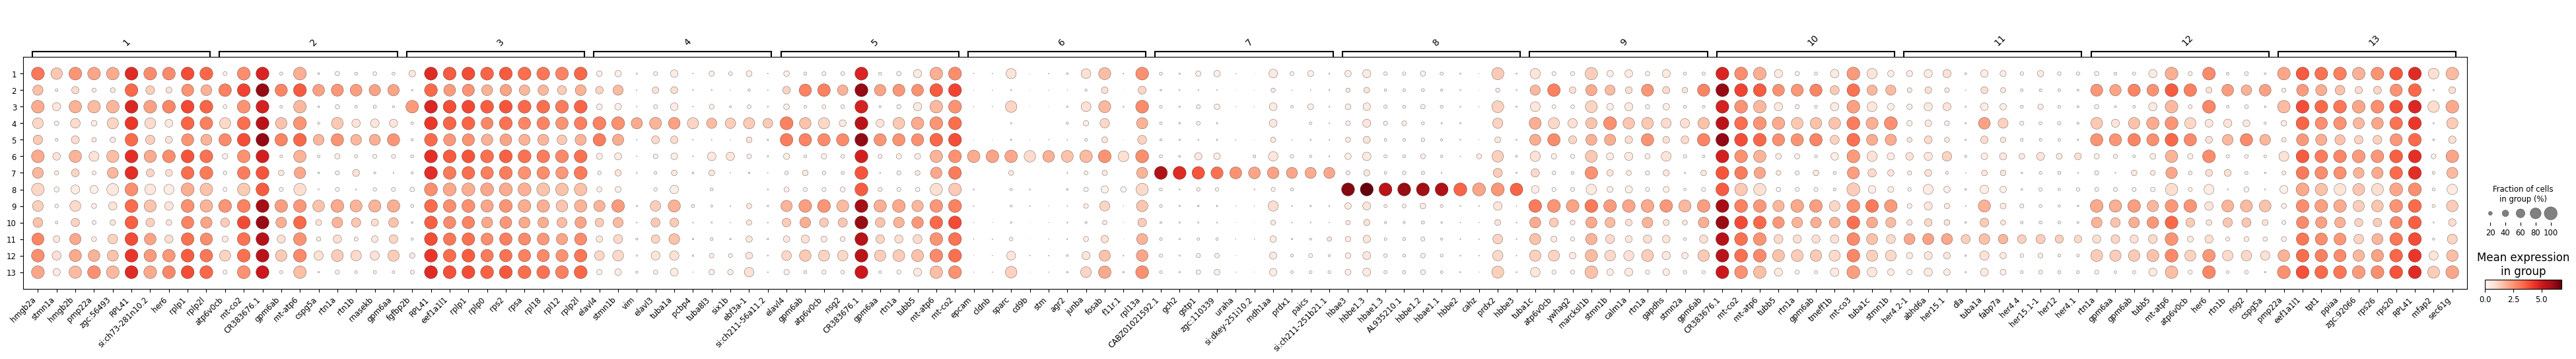

In [15]:
if not rank_genes_column:
    rank_genes_column = f"rank_genes_groups_{clustering_column}"

# Plot dotplot of markers
_ = pl.marker_genes.rank_genes_plot(
    adata,
    key=rank_genes_column,
    n_genes=10,
    style="dots",
    save=f"marker_genes_dots_{clustering_column}.pdf",
    layer=layer,
    report=f"01_marker_genes_dots_{clustering_column}.png"
)

[INFO] Saving figure to ../figures/annotation/compare_annotations.pdf


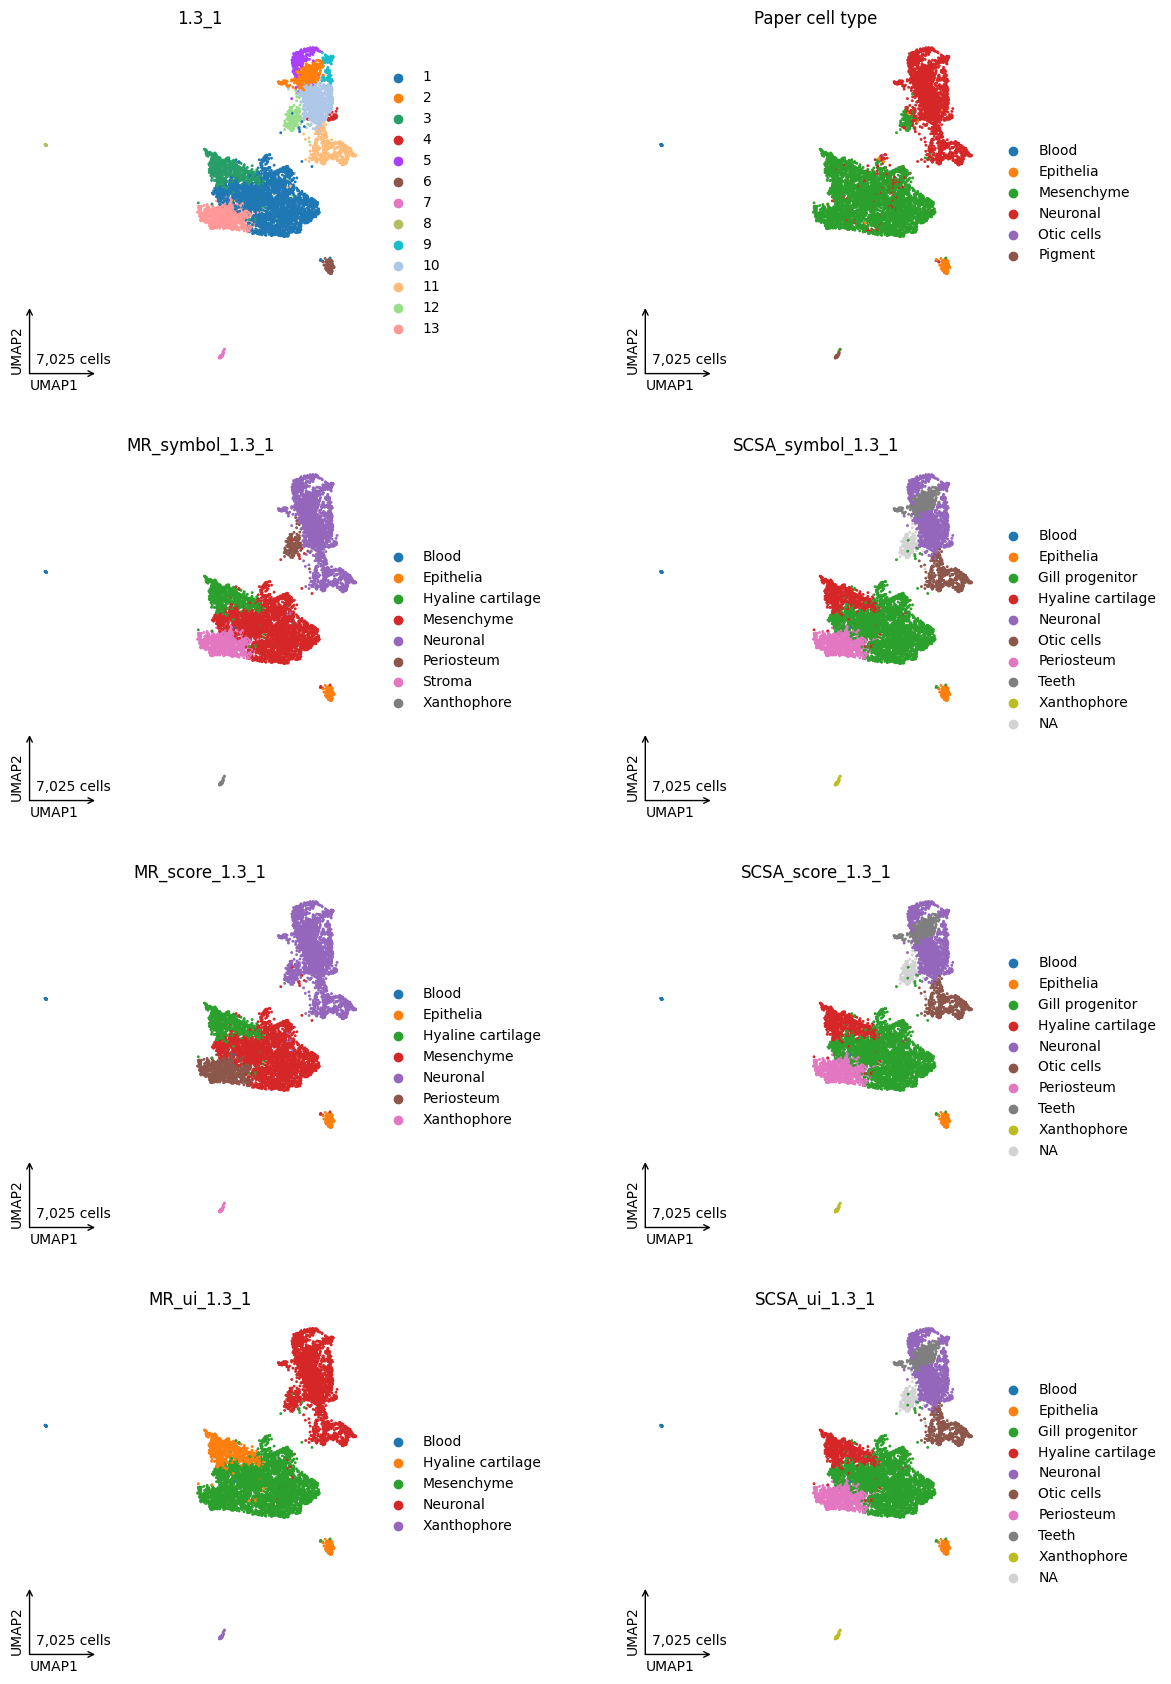

In [16]:
# Plot cell type annotations
columns = [clustering_column] + list(compare_df.columns)
_ = pl.embedding.plot_embedding(adata, method="umap", color=columns, ncols=2,
                                save="compare_annotations.pdf", report="02_compare_annotations.png")

--------------

### 6.1 - Show annotated .obs table

In [17]:
display(adata.obs)

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,leiden,LISI_score_X_pca,LISI_score_X_umap,phase_density,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,1.3_1,clustering,MR_symbol_1.3_1,SCSA_symbol_1.3_1,MR_score_1.3_1,SCSA_score_1.3_1,MR_ui_1.3_1,SCSA_ui_1.3_1
AAACCTGAGATGCGAC-1,8,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,6735.0,8.815222,70.0,4.262680,1.039347,1730.0,7.456455,25.686710,0.058041,False,Male,1809,7.501082,-0.258326,1.878958,G2M,0,1.0,1.0,0.528592,0.225672,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor
AAACCTGAGCGCTCCA-1,13,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,2097.0,7.648740,41.0,3.737670,1.955174,290.0,5.673323,13.829281,0.029984,False,Male,1051,6.958448,-0.194072,-0.051657,G1,2,1.0,1.0,0.571616,0.398501,2,2,4,4,4,2,3,2,3,3,4,4,4,4,6,4,4,2,6,9,9,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
AAACCTGAGTGTACCT-1,13,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,3264.0,8.091015,34.0,3.555348,1.041667,805.0,6.692084,24.662991,0.032669,False,Male,1161,7.057898,-0.261873,-0.232061,G1,2,1.0,1.0,0.496826,0.397672,2,2,4,4,4,2,4,3,4,3,5,5,5,5,7,5,5,3,8,10,10,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
AAACCTGCAAGCCTAT-1,4,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,5510.0,8.614501,68.0,4.234107,1.234120,1976.0,7.589336,35.862072,0.120925,False,Male,1532,7.334982,-0.192147,-0.179321,G1,5,1.0,1.0,0.197381,0.157621,1,1,1,3,3,4,6,3,5,6,7,7,6,7,8,6,6,4,9,12,12,Periosteum,NaN,Neuronal,NaN,Neuronal,NaN
AAACCTGCAAGCTGGA-1,15,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,3719.0,8.221479,25.0,3.258096,0.672224,1824.0,7.509336,49.045444,0.023878,False,Male,926,6.831954,-0.333142,-0.197809,G1,6,1.0,1.0,0.527047,0.500802,1,1,1,3,2,6,6,4,6,7,9,8,8,8,9,7,7,5,11,1,1,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTGGAAAGA-1,2,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,5680.0,8.644882,53.0,3.988984,0.933099,2045.0,7.623642,36.003521,0.047974,False,Male,1475,7.297091,0.163006,0.066747,S,1,1.0,1.0,0.775325,0.890290,1,1,1,1,1,5,2,6,7,2,10,10,9,9,10,8,10,7,5,1,1,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor,Mesenchyme,Gill progenitor
TTTGTCATCCTGCAGG-1,2,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Mesenchyme,6748.0,8.817150,63.0,4.158883,0.933610,2813.0,7.942362,41.686424,0.058041,False,Male,1475,7.297091,0.111096,-0.108790,S,9,1.0,1.0,0.644927,0.692583,1,1,1,1,2,6,7,6,6,10,3,12,3,13,5,15,9,6,18,3,3,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage,Hyaline cartilage
TTTGTCATCTGTGCAA-1,3,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,978.0,6.886532,33.0,3.526361,3.374233,145.0,4.983607,14.826176,0.017345,False,Male,586,6.375025,-0.315206,-0.166030,G1,2,1.0,1.0,0.535586,0.448869,2,2,4,4,4,2,4,3,4,3,5,5,5,5,7,5,5,3,8,10,10,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
TTTGTCATCTTGTACT-1,3,GSM5402430_scRNAseq_Sox10_Cre_bact_BtR_2dpf_re...,GSM5402430,2dpf,rep_1,Neuronal,512.0,6.240276,34.0,3.555348,6.640625,110.0,

In [18]:
# compare annotations to paper
paper_markers = {
    'Blood': ['hbbe2'],
    'Cycling cells': ['mcm4', 'mcm2'],
    'Glia': ['zwi'],
    'Mesenchyme': ['alx4a', 'msx1b', 'prrx1b'],
    'Neuronal': ['neurod1', 'neurod2', 'neurod4', 'neurod6a', 'neurod6b', 'stmn1b'],
    'Otic cells': ['atoh1a'],
    'Pigment': ['mitfa', 'tfec']} # melanocytes

[INFO] Saving figure to ../figures/annotation/marker_repo_score_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

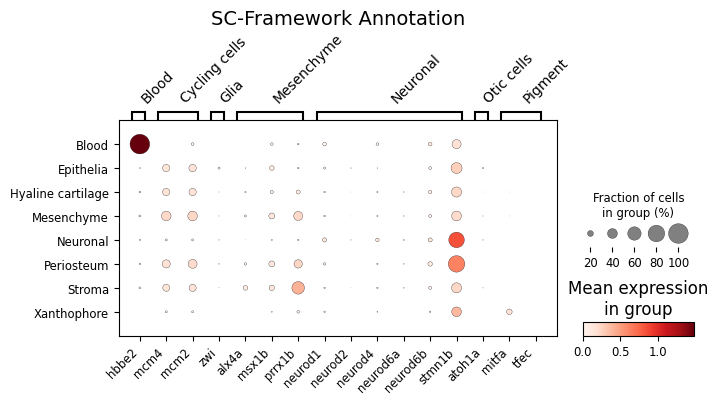

In [19]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="MR_symbol_1.3_1",
    genes=paper_markers,
    log=True,
    title="SC-Framework Annotation",
    save="marker_repo_score_annotation_vs_paper_markers_dotplot.png"
)

[INFO] Saving figure to ../figures/annotation/fabian_et_al_annotation_vs_paper_markers_dotplot.png


{'mainplot_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

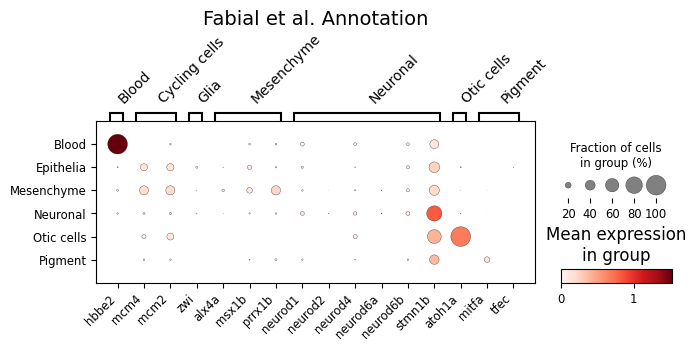

In [20]:
pl.marker_genes.rank_genes_plot(
    adata=adata,
    groupby="Paper cell type",
    genes=paper_markers,
    log=True,
    title="Fabial et al. Annotation",
    save="fabian_et_al_annotation_vs_paper_markers_dotplot.png"
)

--------------

## 7 - Save adata

In [21]:
utils.io.update_yaml({"annotation": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_annotated.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_annotated.h5ad
